# Link Prediction & Structural Inference

This notebook introduces **link prediction** on graphs using classic **topological similarity scores**.

You will:
- Split edges into train/test (avoiding information leakage)
- Sample negative examples (non-edges)
- Compute link scores (CN, Jaccard, Adamic–Adar, Resource Allocation, Preferential Attachment)
- Evaluate with ROC-AUC and PR-AUC

> Notes:
> - We work on **undirected, unweighted** graphs.
> - You will add your own network loading/generation code in the dedicated empty cells.


## 1. Setup

In [33]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import urllib.request

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve


## 2. Load / generate networks 

Add one or more graphs here. For the rest of the notebook, we assume you provide a single graph named `G`.
If your data includes multiple graphs, repeat the pipeline per graph.

In [28]:
def erdos_renyi(N,p,symmetric=True):
    A = np.random.rand(N,N)
    A = A<p
    if symmetric:
        A = np.triu(A,1)
        A = A + A.T
    return A

def generate_sbm(sizes, p_in, p_out,symmetric=True):
    n = sum(sizes)
    adj = np.zeros((n, n))
    # Intra-community links
    start = 0
    for i, size in enumerate(sizes):
        end = start + size
        adj[start:end, start:end] = np.random.rand(size, size) < p_in[i]
        if symmetric:
            #symmetrize
            adj[start:end, start:end] = np.triu(adj[start:end, start:end],1)
            adj[start:end, start:end] = adj[start:end, start:end] + adj[start:end, start:end].T
        start = end
    # Inter-community links
    for i in range(len(sizes)):
        for j in range(i+1, len(sizes)):
            start_i, end_i = sum(sizes[:i]), sum(sizes[:i+1])
            start_j, end_j = sum(sizes[:j]), sum(sizes[:j+1])
            adj[start_i:end_i, start_j:end_j] = np.random.rand(end_i-start_i, end_j-start_j) < p_out[i,j]
            if symmetric:
                adj[start_j:end_j, start_i:end_i] = adj[start_i:end_i, start_j:end_j].T
            else:
                adj[start_j:end_j, start_i:end_i] = np.random.rand(end_j-start_j, end_i-start_i) < p_out[i,j]
    return adj



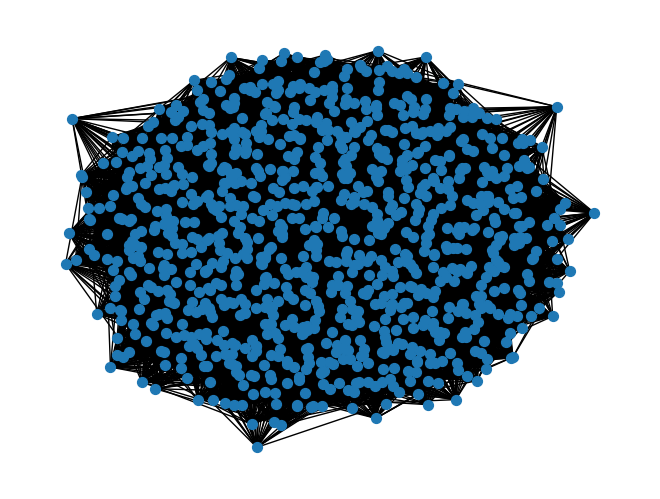

In [29]:
np.random.seed(21)
G_ER= nx.from_numpy_array(erdos_renyi(1000,0.05))
nx.draw(G_ER, node_size=50)


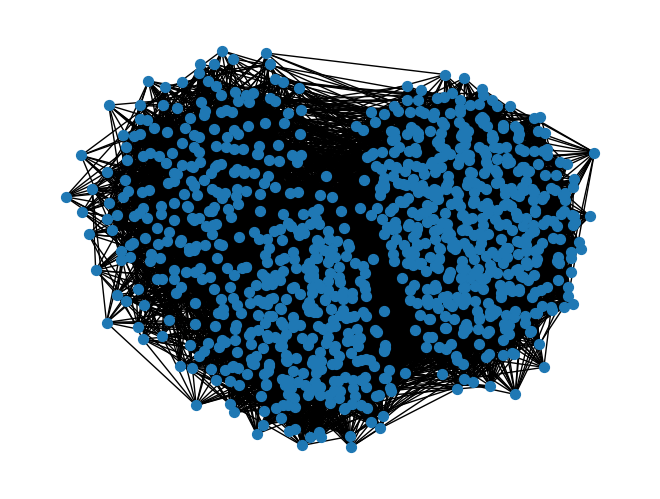

In [30]:
A_SBM=generate_sbm([500,300,200],[0.05,0.07,0.07],
                   np.array([[np.nan,0.01,0.005],
                             [np.nan,np.nan,0.015],
                             [np.nan,np.nan,np.nan]]))
G_SBM=nx.Graph(A_SBM)
nx.draw(G_SBM, node_size=50)

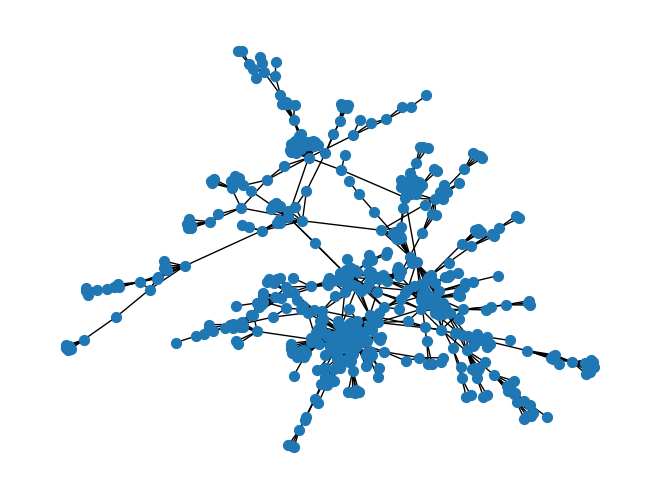

In [34]:
url="https://raw.githubusercontent.com/FraDurazzi/CNLab/refs/heads/master/data/disease_disease_projection_lcc.graphml"
with urllib.request.urlopen(url) as f:
    G_real = nx.read_graphml(f)
nx.draw(G_real, node_size=50)

In [35]:
G=G_real

# Basic checks
assert G is not None, "Please load/generate a graph and assign it to variable G."

# Make it a simple undirected graph (no multi-edges, no self-loops)
G = nx.Graph(G)
G.remove_edges_from(nx.selfloop_edges(G))

# Keep only the largest connected component (common choice for link prediction)
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", nx.density(G))

Nodes: 516
Edges: 1188
Density: 0.008941070219011063


## 3. Train/test split for edges + negative sampling

We remove a fraction of edges to form a **positive test set** and keep a **train graph**.
Then we sample an equal number of **negative test edges** (node pairs that are not edges).

**Important:** all link scores must be computed on `G_train` only.

In [36]:
def split_edges_connected(G, test_frac=0.2, seed=0):
    """Remove ~test_frac of edges while keeping the train graph connected."""
    rng = np.random.default_rng(seed)
    edges = list(G.edges())
    rng.shuffle(edges)

    G_train = G.copy()
    m_test = int(round(test_frac * len(edges)))

    test_pos = []
    removed = 0

    for (u, v) in edges:
        if removed >= m_test:
            break
        # Try removing; keep connected
        G_train.remove_edge(u, v)
        if nx.is_connected(G_train):
            test_pos.append((u, v))
            removed += 1
        else:
            G_train.add_edge(u, v)

    return G_train, test_pos


def sample_negative_edges(G, n_samples, seed=0):
    """Sample non-edges uniformly at random."""
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    non_edges = set()
    E = set(G.edges())
    #E |= {(v, u) for (u, v) in E}  # for undirected check

    while len(non_edges) < n_samples:
        u = rng.choice(nodes)
        v = rng.choice(nodes)
        if u == v:
            continue
        if (u, v) in E:
            continue
        # store canonical ordering
        a, b = (u, v) if u < v else (v, u)
        non_edges.add((a, b))

    return list(non_edges)


In [37]:
# Build split
G_train, test_pos = split_edges_connected(G, test_frac=0.2, seed=0)
test_neg = sample_negative_edges(G, n_samples=len(test_pos), seed=1)

print("Train edges:", G_train.number_of_edges())
print("Test positives:", len(test_pos))
print("Test negatives:", len(test_neg))


Train edges: 950
Test positives: 238
Test negatives: 238


## 4. Similarity scores (core predictors)

Let \(\Gamma(u)\) be the neighbor set of node \(u\).

- **Common Neighbors (CN)**: \(|\Gamma(u)\cap\Gamma(v)|\)
- **Jaccard**: \(|\cap|/|\cup|\)
- **Adamic–Adar (AA)**: \(\sum_{w\in\cap} 1/\log k_w\)
- **Resource Allocation (RA)**: \(\sum_{w\in\cap} 1/k_w\)
- **Preferential Attachment (PA)**: \(k_u k_v\)

We implement scores for a list of candidate pairs.

In [38]:
def _neighbors(G):
    # Precompute neighbor sets for speed and clarity
    return {u: set(G.neighbors(u)) for u in G.nodes()}

def score_cn(G, pairs, neigh=None):
    if neigh is None:
        neigh = _neighbors(G)
    return np.array([len(neigh[u] & neigh[v]) for u, v in pairs], dtype=float)

def score_jaccard(G, pairs, neigh=None):
    if neigh is None:
        neigh = _neighbors(G)
    out = []
    for u, v in pairs:
        inter = neigh[u] & neigh[v]
        union = neigh[u] | neigh[v]
        out.append(len(inter) / len(union) if len(union) > 0 else 0.0)
    return np.array(out, dtype=float)

def score_adamic_adar(G, pairs, neigh=None, deg=None):
    if neigh is None:
        neigh = _neighbors(G)
    if deg is None:
        deg = dict(G.degree())
    out = []
    for u, v in pairs:
        s = 0.0
        for w in (neigh[u] & neigh[v]):
            kw = deg[w]
            if kw > 1:
                s += 1.0 / np.log(kw)
        out.append(s)
    return np.array(out, dtype=float)

def score_resource_allocation(G, pairs, neigh=None, deg=None):
    if neigh is None:
        neigh = _neighbors(G)
    if deg is None:
        deg = dict(G.degree())
    out = []
    for u, v in pairs:
        s = 0.0
        for w in (neigh[u] & neigh[v]):
            kw = deg[w]
            if kw > 0:
                s += 1.0 / kw
        out.append(s)
    return np.array(out, dtype=float)

def score_preferential_attachment(G, pairs, deg=None):
    if deg is None:
        deg = dict(G.degree())
    return np.array([deg[u] * deg[v] for u, v in pairs], dtype=float)


## 5. Evaluation pipeline

We build labels for positives/negatives and compute:
- **ROC-AUC**
- **Average Precision (PR-AUC)**

Then we plot ROC and Precision–Recall curves.

In [39]:
def evaluate_scores(y_true, scores):
    auc = roc_auc_score(y_true, scores)
    ap = average_precision_score(y_true, scores)
    return auc, ap

def plot_roc(y_true, scores_dict):
    plt.figure()
    for name, s in scores_dict.items():
        fpr, tpr, _ = roc_curve(y_true, s)
        plt.plot(fpr, tpr, label=name)
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curves")
    plt.legend()
    plt.show()

def plot_pr(y_true, scores_dict):
    plt.figure()
    for name, s in scores_dict.items():
        p, r, _ = precision_recall_curve(y_true, s)
        plt.plot(r, p, label=name)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall curves")
    plt.legend()
    plt.show()


## 6. Run link prediction

Compute scores on `G_train` for test pairs (positives + negatives).

In [40]:
pairs = test_pos + test_neg
y_true = np.array([1]*len(test_pos) + [0]*len(test_neg))

# Precompute for reuse
neigh = _neighbors(G_train)
deg = dict(G_train.degree())

scores = {}
scores["CN"] = score_cn(G_train, pairs, neigh=neigh)
scores["Jaccard"] = score_jaccard(G_train, pairs, neigh=neigh)
scores["AA"] = score_adamic_adar(G_train, pairs, neigh=neigh, deg=deg)
scores["RA"] = score_resource_allocation(G_train, pairs, neigh=neigh, deg=deg)
scores["PA"] = score_preferential_attachment(G_train, pairs, deg=deg)

# Baseline: random
scores["Random"] = np.random.rand(len(pairs))

# Print metrics
for name, s in scores.items():
    auc, ap = evaluate_scores(y_true, s)
    print(f"{name:8s}  ROC-AUC={auc:.3f}   PR-AUC={ap:.3f}")


CN        ROC-AUC=0.970   PR-AUC=0.963
Jaccard   ROC-AUC=0.969   PR-AUC=0.961
AA        ROC-AUC=0.973   PR-AUC=0.970
RA        ROC-AUC=0.972   PR-AUC=0.968
PA        ROC-AUC=0.728   PR-AUC=0.736
Random    ROC-AUC=0.505   PR-AUC=0.506


In [41]:
pd.Series(scores['CN']).value_counts()

0.0    238
1.0     74
2.0     62
3.0     39
4.0     32
5.0     16
6.0     11
8.0      2
7.0      2
Name: count, dtype: int64

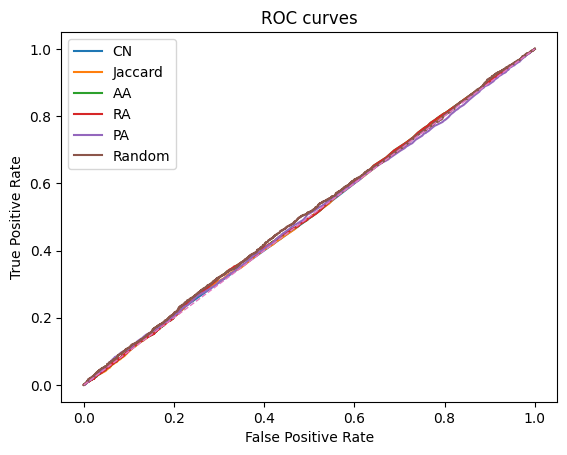

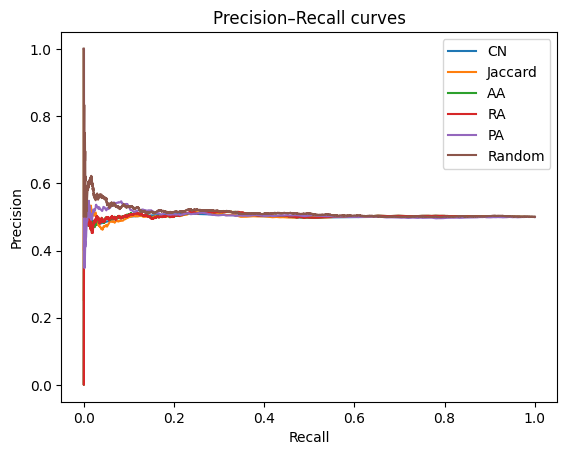

In [26]:
plot_roc(y_true, scores)
plot_pr(y_true, scores)


## Exercises 

1. Change the negative sampling strategy: sample negatives only among pairs at graph distance 2 in `G_train`.
2. Run multiple random splits (different seeds) and report mean ± std of AUC/AP.
3. Build a simple supervised model using features `[CN, Jaccard, AA, RA, PA]`.
